
# <span style="font-size:40px;">**Implémentation d’un VAEr**</span>
Dans ce notebook, on va implémenter un VAE pour générer des images à partir du dataset MNIST. On commence par un autoencodeur classique pour montrer qu’une telle architecture ne permet pas de générer de nouveaux éléments.


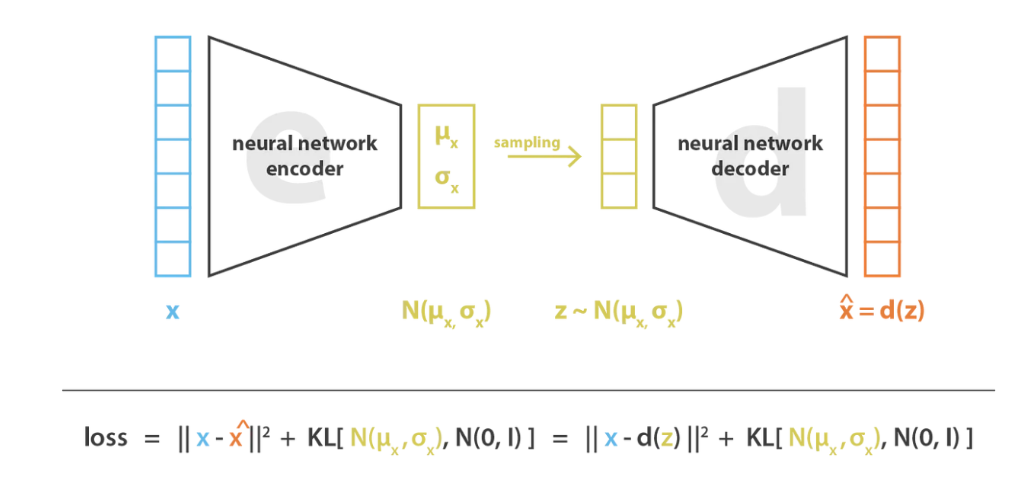

In [36]:
import numpy as np
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
from torchvision import datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt




**Dataset**

On commence par charger le dataset MNIST :


In [37]:
transform = T.Compose([
    T.ToTensor(),
    T.Normalize((0.5,), (0.5,))
])
dataset = datasets.MNIST(root='./../data', train=True, download=True,transform=transform)
test_dataset = datasets.MNIST(root='./../data', train=False,transform=transform)

print("taille du dataset d'entrainement : ",len(dataset))
print("taille d'une image : ",dataset[0][0].numpy().shape)

train_dataset, validation_dataset=torch.utils.data.random_split(dataset, [0.8,0.2])
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader= DataLoader(validation_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

taille du dataset d'entrainement :  60000
taille d'une image :  (1, 28, 28)


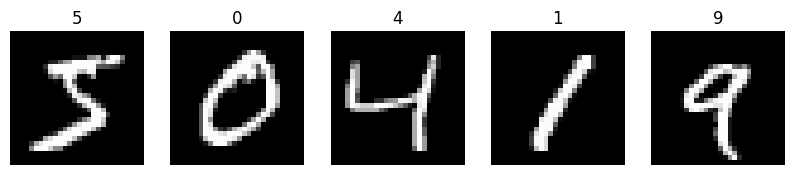

In [38]:
# Visualisons quelques images
plt.figure(figsize=(10, 10))
for i in range(5):
  plt.subplot(1, 5, i+1)
  plt.imshow(dataset[i][0].squeeze(), cmap='gray')
  plt.axis('off')
  plt.title(dataset[i][1])


# <span style="font-size:36px;">**Autoencodeur sur MNIST**</span>


On construit l’architecture de notre autoencodeur :

In [39]:
class AE(nn.Module):
    def __init__(self):
        super(AE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1),  # -> [16, 14, 14]
            nn.ReLU(),
            nn.Conv2d(16, 8, 3, stride=2, padding=1),  # -> [8, 7, 7]
            nn.ReLU(),
            nn.Conv2d(8, 8, 3, stride=2, padding=1)   # -> [8, 4, 4]
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(8, 8, 3, stride=2, padding=1, output_padding=0),
            nn.ReLU(),
            nn.ConvTranspose2d(8, 16, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1),
            nn.Tanh()
        )
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x
dummy_input = torch.randn(1, 1, 28, 28)
model = AE()
output = model(dummy_input)
print(output.shape)

torch.Size([1, 1, 28, 28])


On définit LEs  hyperparamètres d’entraînement :

In [40]:
epochs = 10
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


On passe à l’entraînement du modèle :

In [41]:
for epoch in range(epochs):
    for img,_ in train_loader:
        optimizer.zero_grad()
        recon = model(img)
        loss = criterion(recon, img)
        loss.backward()
        optimizer.step()
    print('epoch [{}/{}], loss:{:.4f}'.format(epoch+1, epochs, loss.item()))

epoch [1/10], loss:0.0357
epoch [2/10], loss:0.0297
epoch [3/10], loss:0.0244
epoch [4/10], loss:0.0238
epoch [5/10], loss:0.0201
epoch [6/10], loss:0.0192
epoch [7/10], loss:0.0183
epoch [8/10], loss:0.0172
epoch [9/10], loss:0.0177
epoch [10/10], loss:0.0199


On vérifie le comportement du modèle sur les données de test :

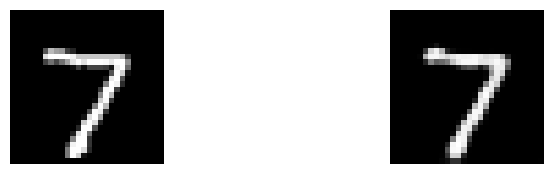

In [23]:
for data in test_loader:
    img, _ = data
    recon = model(img)
    break
plt.figure(figsize=(9, 2))
plt.gray()
plt.subplot(1, 2, 1)
plt.imshow(img[0].detach().numpy().squeeze())
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(recon[0].detach().numpy().squeeze())
plt.axis('off')
plt.show()

On visualise maintenant l’espace latent et la répartition des 10 classes dans cet espace.

In [ ]:
# On commence par extraire les représentations latentes des données de test
latents = []
labels = []

with torch.no_grad():
    for data, target in test_loader:
        latent = model.encoder(data)
        latents.append(latent)
        labels.append(target)

latents = torch.cat(latents)
labels = torch.cat(labels)

On utilise la méthode T-SNE pour extraire des représentations en 2D et visualiser les données.

In [ ]:
from sklearn.manifold import TSNE

latents_flat = latents.view(latents.size(0), -1)
tsne = TSNE(n_components=2, random_state=0)
latent_2d = tsne.fit_transform(latents_flat)

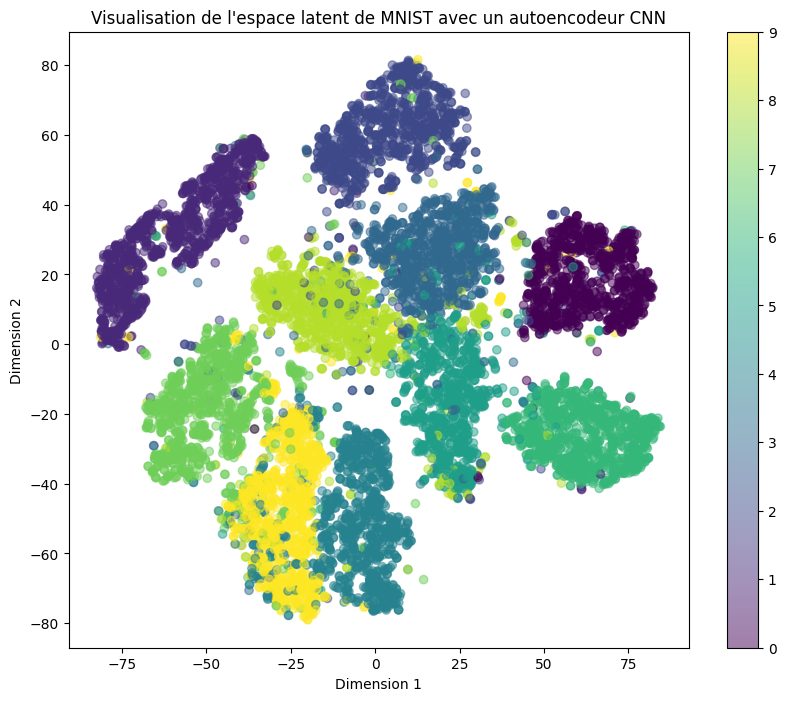

In [ ]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(latent_2d[:, 0], latent_2d[:, 1], c=labels, cmap='viridis', alpha=0.5)
plt.colorbar(scatter)
plt.title('Visualisation de l\'espace latent de MNIST avec un autoencodeur CNN')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.show()

Comme prévu, les classes sont bien séparées dans l’espace latent. Cependant, il y a beaucoup d’espaces vides, ce qui rend difficile le sampling d’un point aléatoire dans l’espace latent et l’espérance de générer une donnée réelle cohérente.

On regarde ce qu’on obtient en générant une image à partir d’un point aléatoire de l’espace latent.

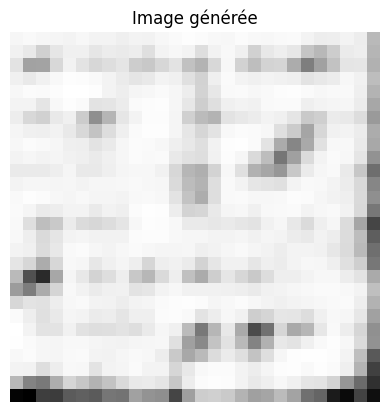

In [ ]:
latent_dim = (8, 4, 4)
sampled_latent = torch.randn(latent_dim).unsqueeze(0)

# On générer l'image avec le décodeur
with torch.no_grad():
    generated_image = model.decoder(sampled_latent)

generated_image = generated_image.squeeze().numpy()  # Supprimer la dimension batch et convertir en numpy
generated_image = (generated_image + 1) / 2  # Dénormaliser l'image (car Tanh est utilisé)
plt.imshow(generated_image, cmap='gray')
plt.title("Image générée")
plt.axis('off')
plt.show()

Comme prévu, cela ne génère rien de cohérent.

# <span style="font-size:36px;">**Variational Autoencoder**</span>





Maintenant, on reprend la même architecture (plus ou moins) mais avec un VAE pour voir si on peut générer des données.

In [43]:
class VAE(nn.Module):
    def __init__(self, latent_dim=16):
        super(VAE, self).__init__()
        # Encodeur (même architecture que ton AE)
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1),  # -> [16,14,14]
            nn.ReLU(),
            nn.Conv2d(16, 8, 3, stride=2, padding=1),  # -> [8,7,7]
            nn.ReLU(),
            nn.Conv2d(8, 8, 3, stride=2, padding=1)    # -> [8,4,4]
        )
        self.fc_mu = nn.Linear(8*4*4, latent_dim)
        self.fc_logvar = nn.Linear(8*4*4, latent_dim)

        # Décodeur
        self.decoder_fc = nn.Sequential(
            nn.Linear(latent_dim, 8*4*4),
            nn.ReLU()
        )
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(8, 8, 3, stride=2, padding=1, output_padding=0),
            nn.ReLU(),
            nn.ConvTranspose2d(8, 16, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1),
            nn.Tanh()
        )

    def encode(self, x):
        h = self.encoder_conv(x)
        h = h.view(h.size(0), -1)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparametrize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.decoder_fc(z)
        h = h.view(h.size(0), 8, 4, 4)
        return self.decoder_conv(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparametrize(mu, logvar)
        return self.decode(z), mu, logvar

dummy_input = torch.randn(1, 1, 28, 28)
model = VAE(latent_dim=8)
output, mu, logvar = model(dummy_input)
print(output.shape, mu.shape, logvar.shape)


torch.Size([1, 1, 28, 28]) torch.Size([1, 8]) torch.Size([1, 8])


In [44]:
epochs = 10
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [45]:
def loss_function(recon_x, x, mu, logvar):
    # Erreur de reconstruction
    MSE = F.mse_loss(recon_x, x, reduction='sum')

    # Terme Kullback–Leibler
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return MSE + KLD


for epoch in range(epochs):
    model.train()
    train_loss = 0

    for data, _ in train_loader:
        optimizer.zero_grad()

        recon, mu, logvar = model(data)

        loss = loss_function(recon, data, mu, logvar)
        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    print(f'Epoch {epoch}, Loss: {train_loss / len(train_loader.dataset)}')


Epoch 0, Loss: 227.9555185953776
Epoch 1, Loss: 128.08219347127277
Epoch 2, Loss: 116.24596551513672
Epoch 3, Loss: 111.05670082600912
Epoch 4, Loss: 107.82865516153971
Epoch 5, Loss: 105.69177939860026
Epoch 6, Loss: 104.02428146362304
Epoch 7, Loss: 102.81397588094076
Epoch 8, Loss: 101.75705102539062
Epoch 9, Loss: 100.80969324747721


In [46]:
latents = []
labels = []

with torch.no_grad():
    for data, target in test_loader:
        mu, logvar = model.encode(data)
        latents.append(mu)
        labels.append(target)

latents = torch.cat(latents)
labels = torch.cat(labels)

In [ ]:
tsne = TSNE(n_components=2, random_state=0)
latent_2d = tsne.fit_transform(latents.view(latents.size(0), -1).cpu().numpy())


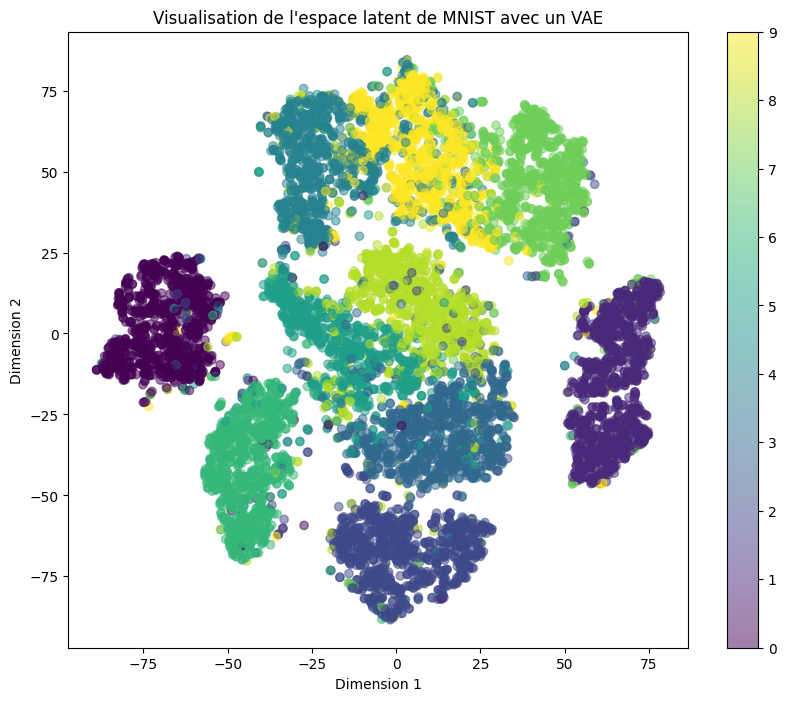

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
scatter = plt.scatter(latent_2d[:, 0], latent_2d[:, 1], c=labels, cmap='viridis', alpha=0.5)
plt.colorbar(scatter)
plt.title('Visualisation de l\'espace latent de MNIST avec un VAE')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.show()

On constate que l’espace latent est encore très éparpillé. Cela s’explique par la différence entre le loss de reconstruction et la divergence de Kullback-Leibler. Dans notre entraînement, le loss de reconstruction était bien plus important que la divergence.

On peut maintenant générer des images. Comme l’espace latent n’a pas les caractéristiques de continuité et de complétude souhaitées, les éléments ne vont pas forcément ressembler à des chiffres réels.

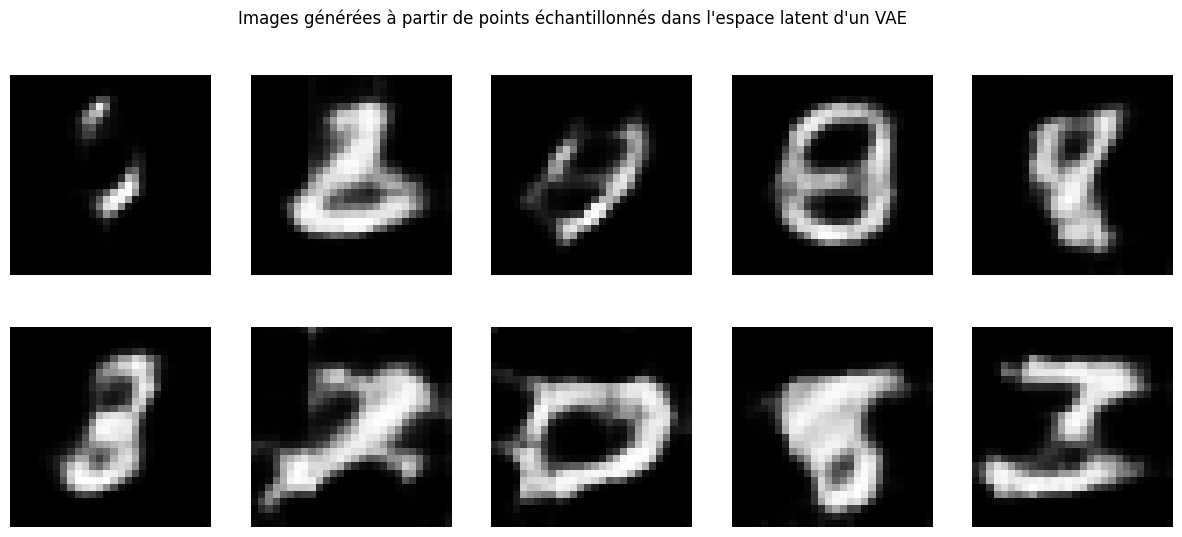

In [ ]:
latent_dim = 8
num_images = 10
images_per_row = 5

sampled_latents = torch.randn(num_images, latent_dim)

with torch.no_grad():
    generated_images = model.decode(sampled_latents)

generated_images = generated_images.squeeze().numpy()  # Supprimer la dimension batch et convertir en numpy
generated_images = (generated_images + 1) / 2  # Dénormaliser les images (car Tanh est utilisé)

fig, axes = plt.subplots(2, images_per_row, figsize=(15, 6))

for i, ax in enumerate(axes.flat):
    ax.imshow(generated_images[i], cmap='gray')
    ax.axis('off')

plt.suptitle("Images générées à partir de points échantillonnés dans l'espace latent d'un VAE")
plt.show()

Comme prévu, certaines images générées n’ont pas vraiment de sens. Comme exercice, vous pouvez essayer d’améliorer la représentation latente pour générer des images cohérentes à chaque fois. Attention, il y a toujours un compromis à faire entre qualité de reconstruction et espace latent.

#Amélioration

In [47]:
class VAE(nn.Module):
    def __init__(self, latent_dim=64):
        super(VAE, self).__init__()
        # Encodeur
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1),  # -> [16,14,14]
            nn.ReLU(),
            nn.Conv2d(16, 8, 3, stride=2, padding=1),  # -> [8,7,7]
            nn.ReLU(),
            nn.Conv2d(8, 8, 3, stride=2, padding=1)    # -> [8,4,4]
        )
        self.fc_mu = nn.Linear(8*4*4, latent_dim)
        self.fc_logvar = nn.Linear(8*4*4, latent_dim)

        # Décodeur
        self.decoder_fc = nn.Sequential(
            nn.Linear(latent_dim, 8*4*4),
            nn.ReLU()
        )
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(8, 8, 3, stride=2, padding=1, output_padding=0),
            nn.ReLU(),
            nn.ConvTranspose2d(8, 16, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1),
            nn.Tanh()
        )

    def encode(self, x):
        h = self.encoder_conv(x)
        h = h.view(h.size(0), -1)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparametrize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.decoder_fc(z)
        h = h.view(h.size(0), 8, 4, 4)
        return self.decoder_conv(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparametrize(mu, logvar)
        return self.decode(z), mu, logvar

dummy_input = torch.randn(1, 1, 28, 28)
model = VAE(latent_dim=8)
output, mu, logvar = model(dummy_input)
print(output.shape, mu.shape, logvar.shape)


torch.Size([1, 1, 28, 28]) torch.Size([1, 8]) torch.Size([1, 8])


In [48]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Normalisation pour Tanh → données dans [-1,1]
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)


In [49]:
import torch.nn.functional as F

def loss_function(recon_x, x, mu, logvar):
    # Reconstruction loss MSE
    MSE = F.mse_loss(recon_x, x, reduction='sum')

    # KL divergence
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return MSE + KLD


In [50]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VAE(latent_dim=8).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
epochs = 25

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for data, _ in train_loader:
        data = data.to(device)

        optimizer.zero_grad()

        recon, mu, logvar = model(data)
        loss = loss_function(recon, data, mu, logvar)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}] - Loss: {total_loss / len(train_loader.dataset):.4f}")


Epoch [1/25] - Loss: 244.5851
Epoch [2/25] - Loss: 129.6064
Epoch [3/25] - Loss: 116.7812
Epoch [4/25] - Loss: 111.0346
Epoch [5/25] - Loss: 107.8441
Epoch [6/25] - Loss: 105.7916
Epoch [7/25] - Loss: 104.2318
Epoch [8/25] - Loss: 102.8874
Epoch [9/25] - Loss: 101.8355
Epoch [10/25] - Loss: 100.8820
Epoch [11/25] - Loss: 100.0192
Epoch [12/25] - Loss: 99.2276
Epoch [13/25] - Loss: 98.5871
Epoch [14/25] - Loss: 98.0185
Epoch [15/25] - Loss: 97.6038
Epoch [16/25] - Loss: 97.1389
Epoch [17/25] - Loss: 96.7570
Epoch [18/25] - Loss: 96.4279
Epoch [19/25] - Loss: 96.1284
Epoch [20/25] - Loss: 95.8416
Epoch [21/25] - Loss: 95.5731
Epoch [22/25] - Loss: 95.3738
Epoch [23/25] - Loss: 95.1522
Epoch [24/25] - Loss: 94.9094
Epoch [25/25] - Loss: 94.7454


In [51]:
latents = []
labels = []

with torch.no_grad():
    for data, target in test_loader:
        data = data.to(device)
        mu, logvar = model.encode(data)

        latents.append(mu.cpu())
        labels.append(target)

latents = torch.cat(latents).numpy()
labels = torch.cat(labels).numpy()


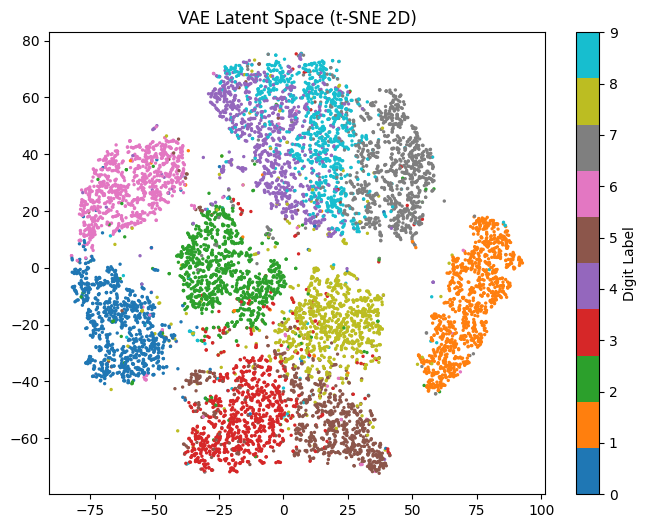

In [52]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, learning_rate=200)
latents_tsne = tsne.fit_transform(latents)

plt.figure(figsize=(8,6))
plt.scatter(latents_tsne[:,0], latents_tsne[:,1], c=labels, s=2, cmap="tab10")
plt.colorbar(label="Digit Label")
plt.title("VAE Latent Space (t-SNE 2D)")
plt.show()


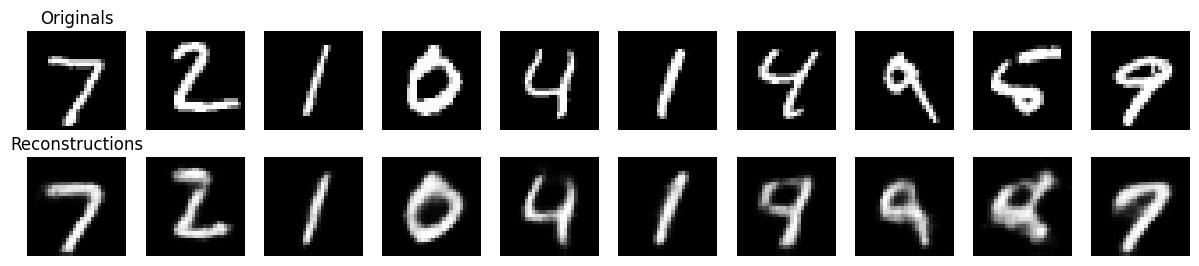

In [53]:
import matplotlib.pyplot as plt

# Prendre un batch du test loader
data, _ = next(iter(test_loader))
data = data.to(device)

# Passer par le modèle
with torch.no_grad():
    recon, _, _ = model(data)

# Remettre sur CPU
data = data.cpu()
recon = recon.cpu()

# Afficher 10 images
n = 10
plt.figure(figsize=(15, 3))

for i in range(n):
    # Images originales
    plt.subplot(2, n, i + 1)
    plt.imshow(data[i].squeeze(), cmap='gray')
    plt.axis('off')
    if i == 0:
        plt.title("Originals")

    # Reconstructions
    plt.subplot(2, n, n + i + 1)
    plt.imshow(recon[i].squeeze(), cmap='gray')
    plt.axis('off')
    if i == 0:
        plt.title("Reconstructions")

plt.show()


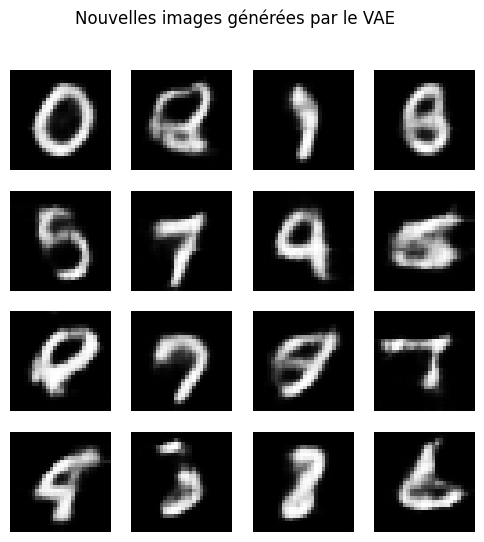

In [73]:
import torch
import matplotlib.pyplot as plt

model.eval()

num_images = 16
latent_dim = model.fc_mu.out_features

# échantillonnage dans N(0,1)
z = torch.randn(num_images, latent_dim).to(device)

# décodage → nouvelles images
with torch.no_grad():
    generated = model.decode(z)

generated = generated.cpu()

# affichage
plt.figure(figsize=(6, 6))
for i in range(num_images):
    plt.subplot(4, 4, i + 1)
    plt.imshow(generated[i].squeeze(), cmap='gray')
    plt.axis('off')

plt.suptitle("Nouvelles images générées par le VAE")
plt.show()


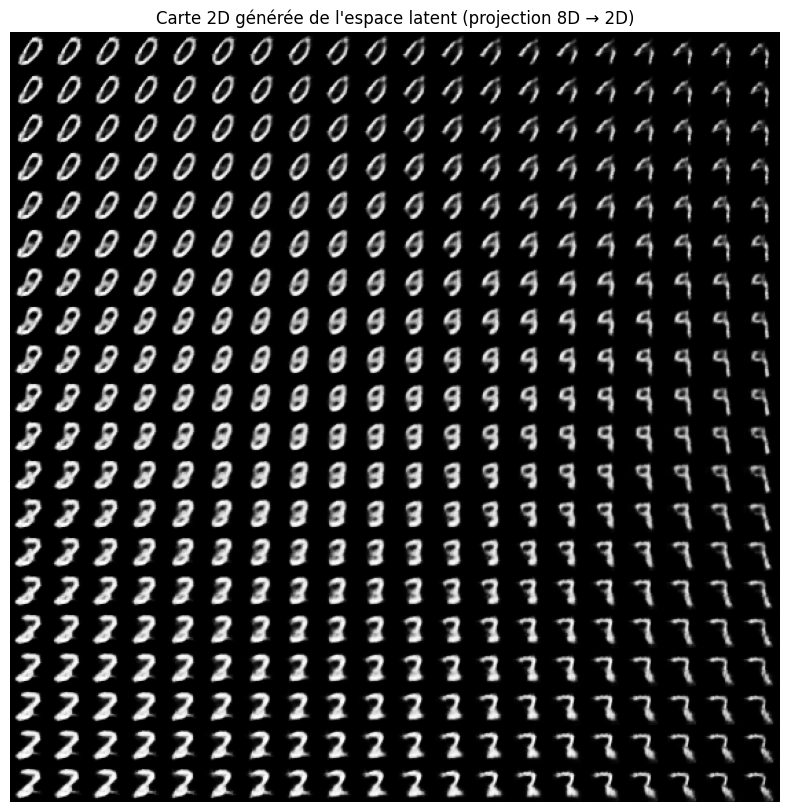

In [57]:
import torch
import numpy as np
import matplotlib.pyplot as plt

model.eval()

grid_size = 20
grid_x = np.linspace(-3, 3, grid_size)
grid_y = np.linspace(-3, 3, grid_size)

# Image finale (grille 20x20 d’images 28x28)
figure = np.zeros((28 * grid_size, 28 * grid_size))

with torch.no_grad():
    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):

            # Création d'un latent 8D : (x,y,0,0,0,0,0,0)
            z = torch.zeros((1, 8))
            z[0, 0] = xi
            z[0, 1] = yi

            z = z.to(device)

            # Décodage
            x_hat = model.decode(z)
            digit = x_hat.cpu().numpy().reshape(28, 28)

            # Placement dans la figure
            figure[
                i * 28 : (i + 1) * 28,
                j * 28 : (j + 1) * 28
            ] = digit

# Affichage
plt.figure(figsize=(10, 10))
plt.imshow(figure, cmap="gray")
plt.axis("off")
plt.title("Carte 2D générée de l'espace latent (projection 8D → 2D)")
plt.show()


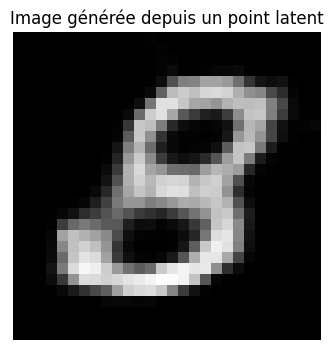

In [64]:
latent_dim = 8

# 1 seul point latent
z = torch.randn(1, latent_dim).to(device)

with torch.no_grad():
    generated = model.decode(z)

# dénormalisation
generated = generated.cpu().squeeze().numpy()
generated = (generated + 1) / 2

plt.figure(figsize=(4,4))
plt.imshow(generated, cmap='gray')
plt.axis('off')
plt.title("Image générée depuis un point latent")
plt.show()
